# Machine Learning-Driven Predictive Modeling of Human Carbonic Anhydrase II Inhibitors



**Author:** [Babak Mamnoon/GitHub]
**Project:** Classification of hCA II Inhibitors using ChEMBL data and ECFP4 Fingerprints.

### Installing Cheminformatics and ML libraries

In [1]:

!pip install rdkit chembl_webresource_client xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import AllChem, rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             confusion_matrix, average_precision_score, accuracy_score)

print("Libraries imported successfully.")

Libraries imported successfully.


### Data Acquisition & Exploration

In [2]:
print("--- Step A: Extracting ChEMBL Dataset ---")

TARGET_ID = 'CHEMBL205'
activity = new_client.activity
res = activity.filter(target_chembl_id=TARGET_ID).filter(standard_type="IC50")

df_raw = pd.DataFrame.from_dict(res)
df = df_raw.dropna(subset=['standard_value', 'canonical_smiles']).copy()
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
df = df.dropna(subset=['standard_value'])

df['class'] = df['standard_value'].apply(lambda x: 1 if x < 1000 else 0)

print(f"Total entries retrieved: {len(df_raw)}")
print(f"Cleaned entries (valid SMILES/IC50): {len(df)}")
print("-" * 30)
display(df[['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'class']].head())

--- Step A: Extracting ChEMBL Dataset ---
Total entries retrieved: 2271
Cleaned entries (valid SMILES/IC50): 1371
------------------------------


,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL544127,CC(C)CN(C)Cc1cc(C(=O)c2csc(S(N)(=O)=O)c2)ccc1O.Cl,9.0,1
1,CHEMBL340519,COc1ccc(C(=O)c2coc(S(N)(=O)=O)c2)cc1,2.0,1
2,CHEMBL541089,CN(C)Cc1cc(C(=O)c2csc(S(N)(=O)=O)c2)ccc1O.Cl,6.4,1
3,CHEMBL555153,Cl.NS(=O)(=O)c1cc(S(=O)(=O)c2ccc(CN3CCOCC3)cc2...,7.6,1
4,CHEMBL539817,CC(C)CN(C)Cc1cc(S(=O)(=O)c2csc(S(N)(=O)=O)c2)c...,5.0,1


### Molecular Featurization (ECFP4)

In [3]:
print("--- Step B: Converting SMILES to Morgan Fingerprints ---")

# Create Morgan fingerprint generator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048)

def generate_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        fp = morgan_gen.GetFingerprint(mol)

        # Convert RDKit ExplicitBitVect to NumPy array
        arr = np.zeros((2048,), dtype=int)
        Chem.DataStructs.ConvertToNumpyArray(fp, arr)

        return arr

    return None

df['fp'] = df['canonical_smiles'].apply(generate_fp)
df = df.dropna(subset=['fp']).reset_index(drop=True)

X = np.stack(df['fp'].values)
y = df['class'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

--- Step B: Converting SMILES to Morgan Fingerprints ---
Training set shape: (1096, 2048)
Testing set shape: (275, 2048)


### Model Training & Evaluation

Processing Logistic Regression...


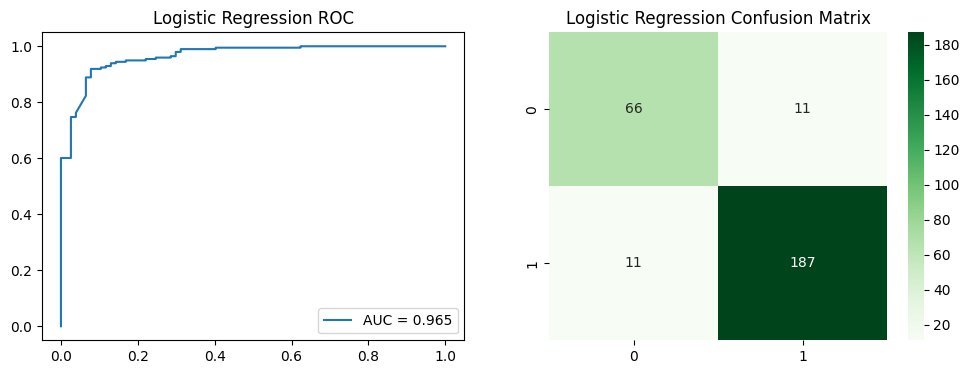

Processing Random Forest...


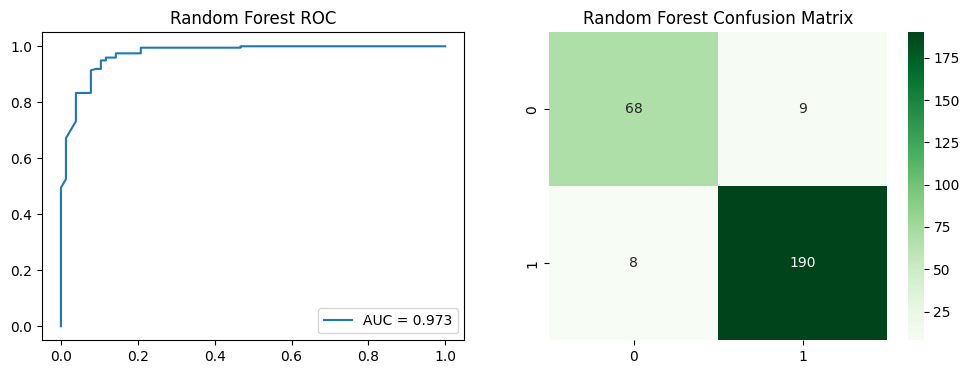

Processing SVM (RBF)...


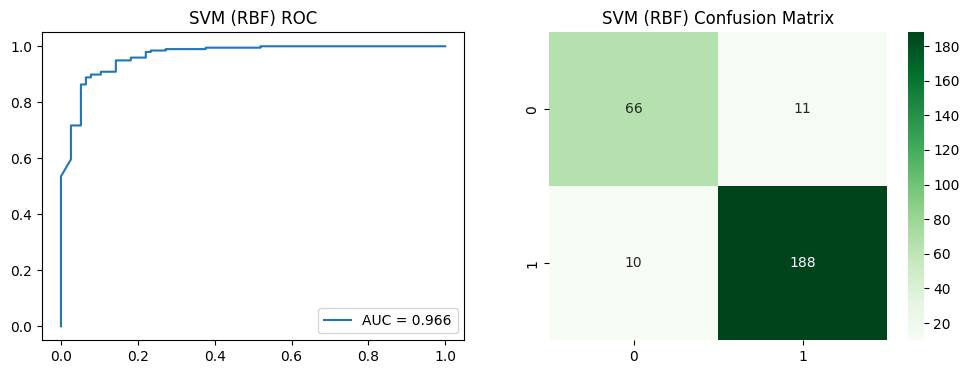

Processing XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:55:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


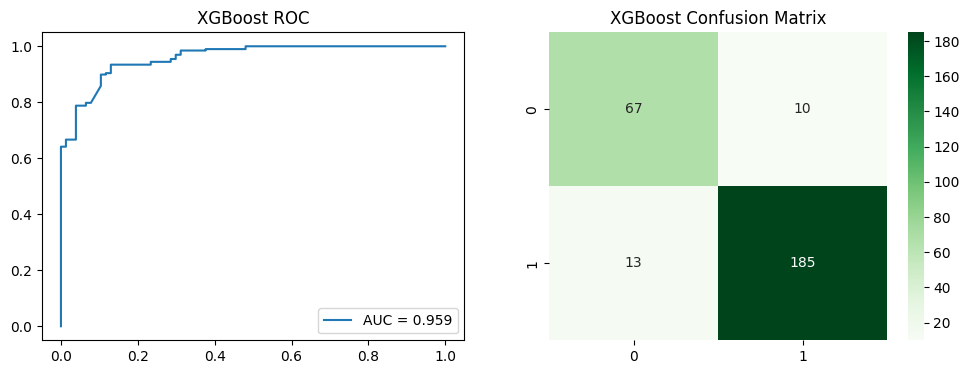

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

performance_log = {}

for name, model in models.items():
    print(f"Processing {name}...")
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]
    y_preds = model.predict(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    performance_log[name] = {"ROC-AUC": roc_auc, "Accuracy": accuracy_score(y_test, y_preds)}

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    ax[0].set_title(f'{name} ROC')
    ax[0].legend()

    cm = confusion_matrix(y_test, y_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax[1])
    ax[1].set_title(f'{name} Confusion Matrix')
    plt.show()

### Final Comparison

In [9]:
sorted_summary = sorted(performance_log.items(), key=lambda x: x[1]['ROC-AUC'], reverse=True)

print("\nFINAL SCIENTIFIC CONCLUSION")

for i, (name, stats) in enumerate(sorted_summary):
    print(f"{i+1}. {name}:")
    print(f"   - ROC-AUC: {stats['ROC-AUC']:.3f} (±{stats['ROC-AUC']:.3f})")
    print(f"   - Accuracy: {stats['Accuracy']:.1%}")


FINAL SCIENTIFIC CONCLUSION
1. Random Forest:
   - ROC-AUC: 0.973 (±0.973)
   - Accuracy: 93.8%
2. SVM (RBF):
   - ROC-AUC: 0.966 (±0.966)
   - Accuracy: 92.4%
3. Logistic Regression:
   - ROC-AUC: 0.965 (±0.965)
   - Accuracy: 92.0%
4. XGBoost:
   - ROC-AUC: 0.959 (±0.959)
   - Accuracy: 91.6%
